In [11]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

sys.path.append(os.path.abspath('../src'))
from preprocess import preprocess_data
from train import train_xgb
from evaluate import evaluate_model, build_importance_df

# Load the dataset
df = pd.read_csv('../data/raw/load_forecasting_dataset.csv')
df.head()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325


In [12]:
preprocess_result = preprocess_data(df, scaler_path='../models/scaler.pkl')
df_processed = preprocess_result['df_processed']
X = preprocess_result['X']
y = preprocess_result['y']
X_train = preprocess_result['X_train']
X_val = preprocess_result['X_val']
X_test = preprocess_result['X_test']
y_train = preprocess_result['y_train']
y_val = preprocess_result['y_val']
y_test = preprocess_result['y_test']
X_train_scaled = preprocess_result['X_train_scaled']
X_val_scaled = preprocess_result['X_val_scaled']
X_test_scaled = preprocess_result['X_test_scaled']
scaler = preprocess_result['scaler']

print('Preprocessing complete. Scaler saved.')

Preprocessing complete. Scaler saved.


In [13]:
print("Sample preprocessed data (first 10 rows):")
display(df_processed.head(10))

print("\nShape:", df_processed.shape)

Sample preprocessed data (first 10 rows):


,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Public Event,Load Demand (kW),Season_Fall,Season_Summer,Season_Winter,is_weekend
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,0,1599.342831,False,True,False,0
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,0,1472.347140,False,True,False,0
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,0,1629.537708,False,True,False,0
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,1,1804.605971,False,True,False,0
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,0,1453.169325,False,True,False,0
5,1/1/2020 1:15,27.531726,79.342322,2.879259,8.921799,204.113322,906.307089,517.742133,26.050655,2,1,1,0,1453.172609,False,True,False,0
6,1/1/2020 1:30,31.158426,71.645943,0.880808,0.544923,247.400541,800.427592,496.439128,23.220658,2,1,1,0,1815.842563,False,True,False,0
7,1/1/2020 1:45,29.534869,85.227175,2.943079,1.550244,262.270821,1100.524882,520.289429,20.884973,2,1,1,0,1653.486946,False,True,False,0
8,1/1/2020 2:00,27.061051,85.387375,3.005157,6.730992,321.956621,1052.210403,501.196614,30.661501,2,2,1,0,1406.105123,False,True,False,0
9,1/1/2020 2:15,29.085120,82.334175,1.561072,3.680875,246.566294,932.621599,491.054875,31.952302,2,2,1,0,1608.512009,False,True,False,0



Shape: (189888, 18)


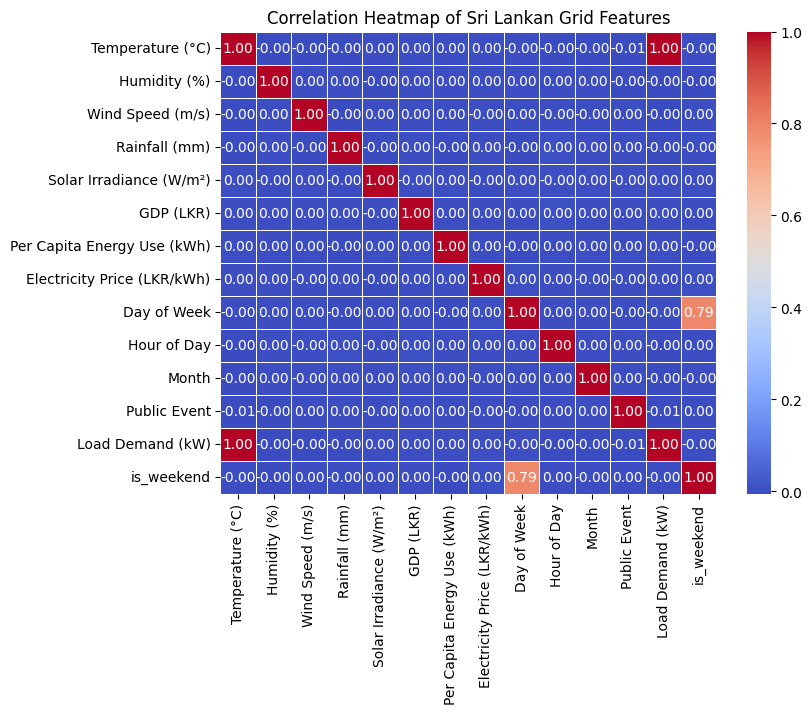

In [14]:
# 1. Calculate the correlation matrix using only numeric columns
numeric_df = df_processed.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# 2. Create the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Sri Lankan Grid Features')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_6596\1460358830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_weekend', y='Load Demand (kW)', data=df_processed, palette='Set2')


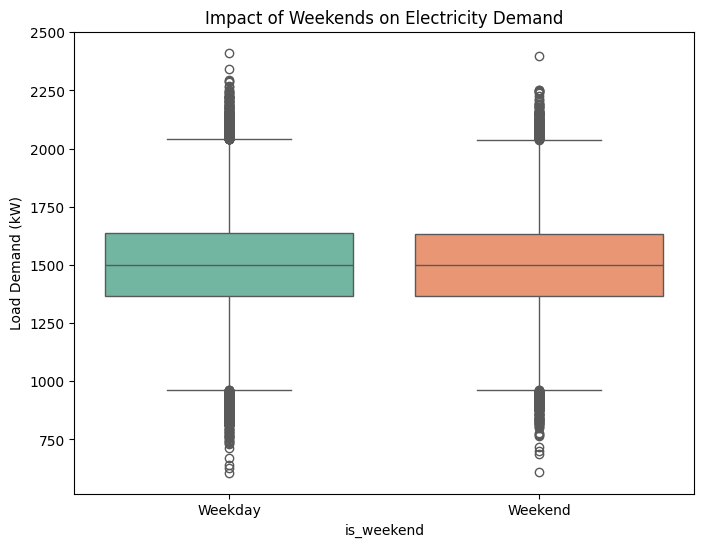

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_weekend', y='Load Demand (kW)', data=df_processed, palette='Set2')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title('Impact of Weekends on Electricity Demand')
plt.show()

In [16]:
# Initialize and train XGBoost
model = train_xgb(
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    model_path='../models/trained_model.pkl',
    verbose=100,
 )

print('Model trained and saved to models/trained_model.pkl')

[0]	validation_0-rmse:189.79658
[100]	validation_0-rmse:6.25097
[200]	validation_0-rmse:6.26930
[300]	validation_0-rmse:6.51920
[400]	validation_0-rmse:6.60812
[499]	validation_0-rmse:6.62376
Model trained and saved to models/trained_model.pkl


<Figure size 1000x800 with 0 Axes>

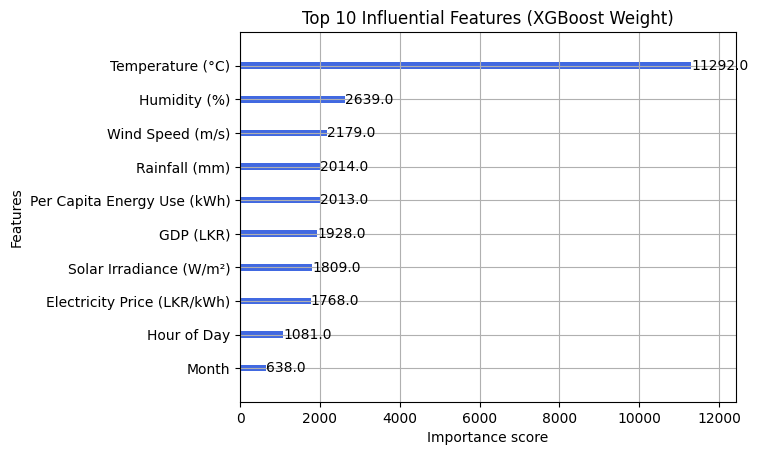

In [21]:
# Top 10 features by importance (with real feature names)
booster = model.get_booster()
booster.feature_names = X_train.columns.tolist()

plt.figure(figsize=(10, 8))
xgb.plot_importance(booster, max_num_features=10, importance_type='weight', color='royalblue')
plt.title('Top 10 Influential Features (XGBoost Weight)')
plt.show()

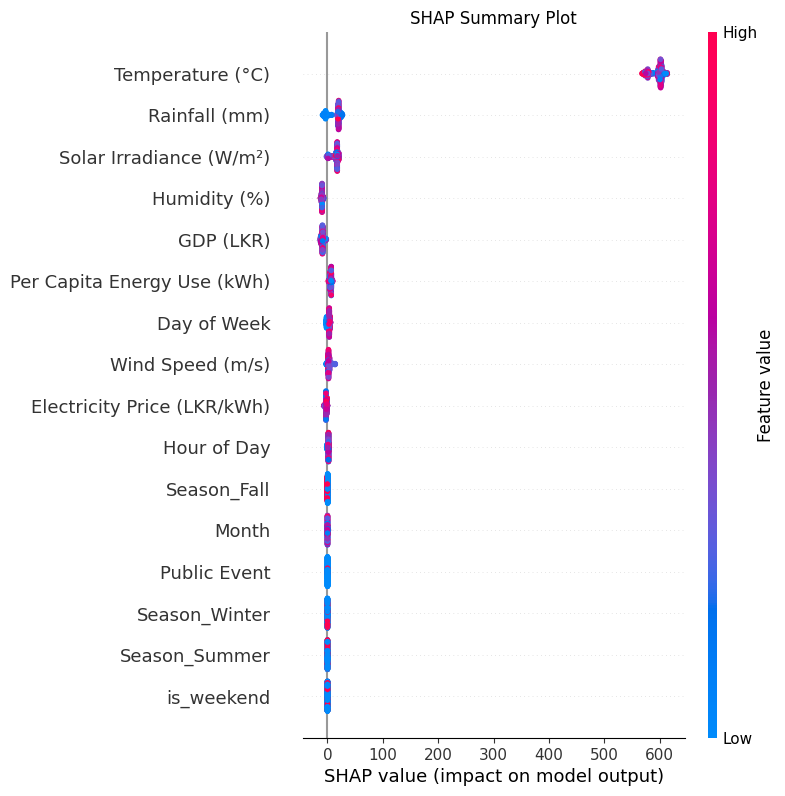

In [18]:
# SHAP summary plot (red/blue)
sample_size = min(500, len(X_test))
X_shap = X_test.sample(sample_size, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Summary Plot')
plt.show()

In [19]:
# Predictions and metrics
eval_result = evaluate_model(model, X_test_scaled, y_test)
preds = eval_result['preds']
rmse = eval_result['rmse']
r2 = eval_result['r2']

print(f"Test RMSE: {rmse:.2f} kW")
print(f"Test R2 Score: {r2:.4f}")



Test RMSE: 6.15 kW
Test R2 Score: 0.9991


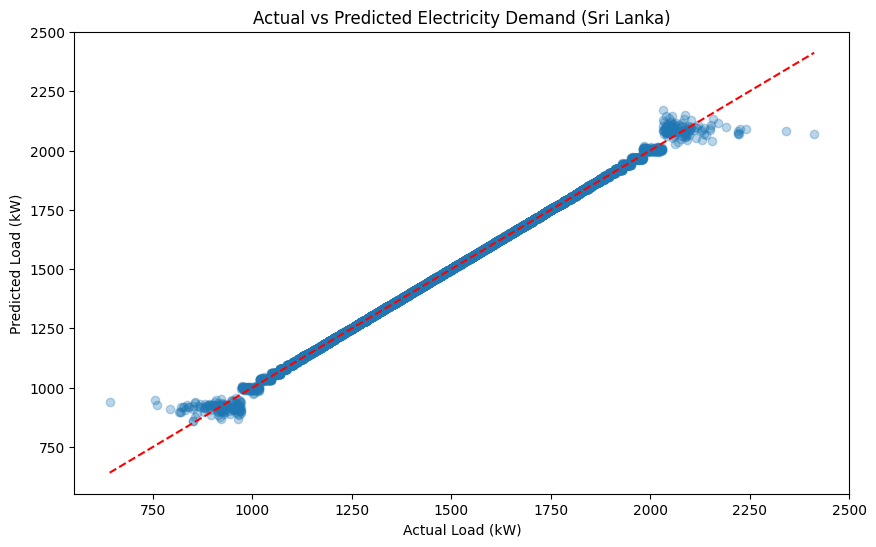

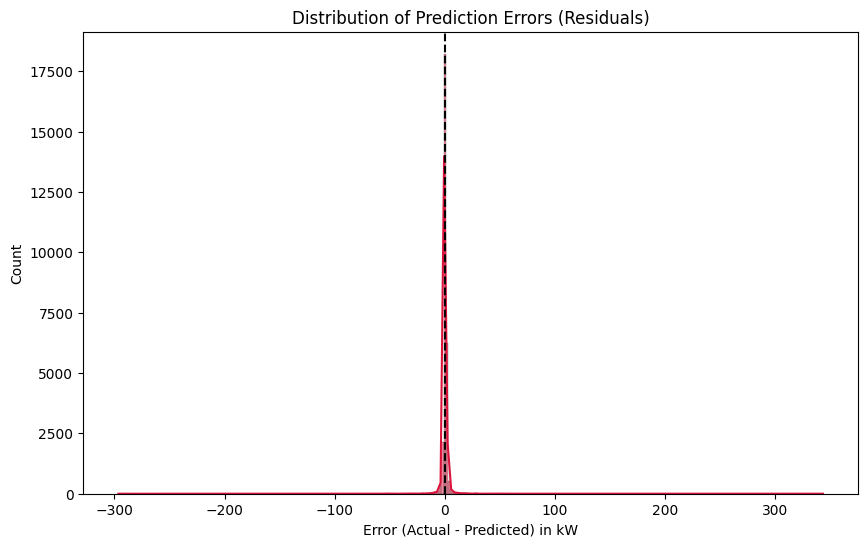

In [20]:
# Plot Actual vs Predicted
plt.figure(figsize=(10,6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Load (kW)')
plt.ylabel('Predicted Load (kW)')
plt.title('Actual vs Predicted Electricity Demand (Sri Lanka)')
plt.show()

#Residuals plot
residuals = y_test - preds
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='crimson')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in kW')
plt.show()